# Kaggle Deep Learning Baselines

This notebook trains and evaluates two deep learning models — TextCNN and BiLSTM — on the processed Kaggle human and LLM-generated phishing email dataset using the PyTorch framework. Both models use learned word embeddings (randomly initialised and trained end-to-end) and are evaluated using the same metrics schema as all other models in this project for direct comparison.

> **Note on framework choice:** The MeAJOR deep learning notebook uses Keras/TensorFlow. PyTorch was chosen here to demonstrate cross-framework portability and because its `pack_padded_sequence` API makes variable-length BiLSTM processing more explicit. Both notebooks share the same evaluation schema (Accuracy, Precision, Recall, F1, FPR, Inference Time), so cross-dataset comparison remains valid at the results level.

## 1. Import Libraries

All libraries needed for loading data, building and training deep learning models, and evaluating and saving results are imported here.

In [1]:
import os
import time
import random
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence
from collections import Counter

# Metrics for evaluating model performance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

## 2. Reproducibility and Configuration

A fixed random seed is set across all libraries to ensure reproducible results. All key hyperparameters and file paths are defined here in one place.

In [2]:
SEED = 42

def set_seed(seed):
    # Fix all sources of randomness for reproducibility
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# File paths
data_dir    = Path("../data/processed/kaggle/")
glove_path  = Path("../data/glove/glove.6B.100d.txt")
results_dir = Path("../results/")
results_dir.mkdir(parents=True, exist_ok=True)

# Hyperparameters: consistent with meajor_dl_baselines.ipynb where applicable
EMBED_DIM        = 100
MAX_LEN          = 200
VOCAB_SIZE       = 20000
BATCH_SIZE       = 32
LEARNING_RATE    = 1e-3
NUM_EPOCHS       = 10
DROPOUT          = 0.5

# TextCNN: parallel filters capture bigram, trigram, and 4-gram patterns
CNN_FILTER_SIZES = [2, 3, 4]
CNN_NUM_FILTERS  = 128

# BiLSTM
LSTM_HIDDEN      = 128
LSTM_LAYERS      = 2

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cpu


## 3. Load Processed Data

The train and test Parquet files produced by `kaggle_preparation.ipynb` are loaded here. These contain the cleaned `text` and `label` columns only.

In [3]:
# Load the 60% training split
train_df = pd.read_parquet(data_dir / "kaggle_train_60.parquet")

# Load the 40% test split
test_df  = pd.read_parquet(data_dir / "kaggle_test_40.parquet")

print(f"Train size:  {len(train_df)} rows")
print(f"Test size:   {len(test_df)} rows")
print(f"Columns:     {train_df.columns.tolist()}")

Train size:  1435 rows
Test size:   957 rows
Columns:     ['text', 'label', 'source']


## 4. Verify Loaded Data

A quick check of label distributions and a sample of the text field to confirm the data loaded correctly before building the vocabulary.

In [4]:
print("Train label distribution:")
print(train_df["label"].value_counts())

print("\nTest label distribution:")
print(test_df["label"].value_counts())

# Preview a few rows to confirm the text field looks correct
train_df[["text", "label"]].head(3)

Train label distribution:
label
0    1034
1     401
Name: count, dtype: int64

Test label distribution:
label
0    690
1    267
Name: count, dtype: int64


,text,label
0,Rachel Thompson COVID-19 Vaccination Team,1
1,Notification: jose@monkey.org Dear jose To c...,1
2,ActiveState evaluation license for Komodo IDE ...,0


## 5. Tokenisation and Vocabulary

The text is split on whitespace, it is already lowercased and cleaned from the preparation notebook. A vocabulary of the most frequent tokens is built from the training set only to avoid data leakage.

In [5]:
def simple_tokenise(text):
    # Text is already lowercased; split on whitespace only
    return str(text).split()

# Build vocabulary from training data only, no test set leakage
all_tokens = []
for text in train_df["text"]:
    all_tokens.extend(simple_tokenise(text))

token_counts = Counter(all_tokens)

# Index 0 = <PAD> (padding), Index 1 = <UNK> (unknown tokens)
most_common = [tok for tok, _ in token_counts.most_common(VOCAB_SIZE - 2)]
vocab = {"<PAD>": 0, "<UNK>": 1}
for tok in most_common:
    vocab[tok] = len(vocab)

print(f"Vocabulary size: {len(vocab)}")


def encode(text, max_len):
    # Convert text to a fixed-length integer sequence
    tokens = simple_tokenise(text)[:max_len]
    ids    = [vocab.get(t, vocab["<UNK>"]) for t in tokens]
    # Pad with zeros up to max_len if the sequence is shorter
    ids   += [0] * (max_len - len(ids))
    # Also return actual length for BiLSTM packed sequence
    return ids, min(len(tokens), max_len)

Vocabulary size: 20000


## 6. PyTorch Dataset and DataLoaders

A custom Dataset class encodes each email into a padded integer sequence. A 10% validation split is taken from the training set. DataLoaders are created for train, validation, and test sets.

In [6]:
class EmailDataset(Dataset):
    def __init__(self, df, max_len):
        self.labels    = df["label"].values
        self.encodings = []
        self.lengths   = []
        for text in df["text"]:
            ids, length = encode(text, max_len)
            self.encodings.append(ids)
            self.lengths.append(length)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.encodings[idx], dtype=torch.long),
            torch.tensor(self.lengths[idx],   dtype=torch.long),
            torch.tensor(self.labels[idx],    dtype=torch.float)
        )

# Hold out 10% of training data as a validation set
# Hold out a random 10% of training data as a validation set
# Using random sampling avoids row-order bias in the validation set
val_sub   = train_df.sample(frac=0.1, random_state=SEED)
train_sub = train_df.drop(val_sub.index).reset_index(drop=True)
val_sub   = val_sub.reset_index(drop=True)

train_dataset = EmailDataset(train_sub, MAX_LEN)
val_dataset   = EmailDataset(val_sub,   MAX_LEN)
test_dataset  = EmailDataset(test_df,   MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Train batches: 41 | Val batches: 5 | Test batches: 30


## 7. Model Definitions

TextCNN uses parallel convolutional filters of different sizes to capture bigram, trigram, and 4-gram patterns, followed by global max pooling and a classification head. BiLSTM processes the token sequence in both directions and classifies using the concatenated final hidden states.

**Why these two architectures?**

- **TextCNN** — Parallel convolutional filters efficiently detect local n-gram patterns strongly indicative of phishing (suspicious URLs, urgent phrasing, credential-capture phrases) without sequential computation. This makes it fast at inference time and well-suited to structured, relatively short email text.

- **BiLSTM** — Bidirectional recurrent processing captures long-range sequential dependencies (e.g. a qualifying clause later in the email that changes the meaning of an earlier phrase) that fixed-width CNN filters may miss. The trade-off is higher inference latency compared to TextCNN.

In [7]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim,
                 filter_sizes, num_filters, dropout):
        super(TextCNN, self).__init__()

        # Trainable embedding layer initialised randomly
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # One Conv1d per filter size to capture different n-gram window patterns
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim, out_channels=num_filters, kernel_size=fs)
            for fs in filter_sizes
        ])

        self.dropout = nn.Dropout(dropout)
        # Concatenated max-pooled outputs from all filter sizes → single logit
        self.fc = nn.Linear(len(filter_sizes) * num_filters, 1)

    def forward(self, x, lengths=None):
        emb = self.embedding(x)           # (batch, seq_len, embed_dim)
        emb = emb.permute(0, 2, 1)        # (batch, embed_dim, seq_len) - required for Conv1d

        pooled = []
        for conv in self.convs:
            c = torch.relu(conv(emb))     # (batch, num_filters, seq_len - fs + 1)
            # Global max pooling: take the single strongest activation per filter
            c = torch.max(c, dim=2).values
            pooled.append(c)

        out = torch.cat(pooled, dim=1)    # (batch, len(filter_sizes) * num_filters)
        out = self.dropout(out)
        return self.fc(out).squeeze(1)    # (batch,) — raw logit


class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim,
                 hidden_dim, num_layers, dropout):
        super(BiLSTM, self).__init__()

        # Trainable embedding layer initialised randomly
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)
        # hidden_dim * 2 because bidirectional concatenates forward + backward directions
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x, lengths):
        emb = self.embedding(x)
        # Pack padded sequence so padding tokens do not affect hidden state
        packed = pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (hidden, _) = self.lstm(packed)
        # hidden[-2] = last layer forward direction; hidden[-1] = last layer backward
        final = torch.cat([hidden[-2], hidden[-1]], dim=1)
        final = self.dropout(final)
        return self.fc(final).squeeze(1)

## 8. Training and Evaluation Functions

Shared utility functions handle one epoch of training, per-epoch validation, final test evaluation, and inference time measurement. These are used identically for both models.

In [8]:
def train_epoch(model, loader, optimiser, criterion, device):
    model.train()
    total_loss = 0.0
    for sequences, lengths, labels in loader:
        sequences, lengths, labels = sequences.to(device), lengths.to(device), labels.to(device)
        optimiser.zero_grad()
        logits = model(sequences, lengths)
        loss   = criterion(logits, labels)
        loss.backward()
        optimiser.step()
        total_loss += loss.item() * len(labels)
    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for sequences, lengths, labels in loader:
            sequences, lengths, labels = sequences.to(device), lengths.to(device), labels.to(device)
            logits = model(sequences, lengths)
            loss   = criterion(logits, labels)
            total_loss += loss.item() * len(labels)
            preds = (torch.sigmoid(logits) >= 0.5).long().cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().long().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc      = accuracy_score(all_labels, all_preds)
    prec     = precision_score(all_labels, all_preds, zero_division=0)
    rec      = recall_score(all_labels, all_preds, zero_division=0)
    f1       = f1_score(all_labels, all_preds, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(all_labels, all_preds).ravel()
    fpr      = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    return avg_loss, acc, prec, rec, f1, fpr, all_labels, all_preds


def measure_inference_time(model, loader, device, n_runs=3):
    """Measure model-only inference time, excluding DataLoader overhead.
    Pre-converts the full test set to a single tensor so that batch
    construction and data-transfer costs are not included in the timing."""
    model.eval()
    # Pre-collect all batches into single tensors to exclude DataLoader overhead
    all_seqs, all_lens = [], []
    for sequences, lengths, _ in loader:
        all_seqs.append(sequences)
        all_lens.append(lengths)
    all_seqs = torch.cat(all_seqs, dim=0).to(device)
    all_lens  = torch.cat(all_lens,  dim=0).to(device)

    times = []
    with torch.no_grad():
        for _ in range(n_runs):
            start = time.perf_counter()
            _ = model(all_seqs, all_lens)
            end   = time.perf_counter()
            times.append((end - start) * 1000)  # ms
    # Average across runs, then divide by number of emails
    return round(np.mean(times) / len(all_seqs), 4)

## 9. Train Both Models

Each model is trained for the configured number of epochs. Per-epoch training loss and validation metrics are printed to track progress and detect overfitting.

In [9]:
def run_training(model_name, model, train_loader, val_loader, num_epochs, lr, device):
    criterion = nn.BCEWithLogitsLoss()
    # Only optimise parameters that are not frozen (i.e. everything except embeddings)
    optimiser = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}

    print(f"\n{'='*65}")
    print(f"  Training {model_name}")
    print(f"{'='*65}")
    print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>9} | {'Val Acc':>8} | {'Val F1':>7} | {'Val FPR':>8}")
    print("-" * 65)

    for epoch in range(1, num_epochs + 1):
        train_loss = train_epoch(model, train_loader, optimiser, criterion, device)
        val_loss, val_acc, _, _, val_f1, val_fpr, _, _ = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        print(f"{epoch:>5} | {train_loss:>10.4f} | {val_loss:>9.4f} | {val_acc:>7.2%} | {val_f1:>7.4f} | {val_fpr:>8.4f}")

    return history


# Instantiate models
textcnn = TextCNN(len(vocab), EMBED_DIM, CNN_FILTER_SIZES, CNN_NUM_FILTERS, DROPOUT).to(DEVICE)
bilstm  = BiLSTM(len(vocab), EMBED_DIM, LSTM_HIDDEN, LSTM_LAYERS, DROPOUT).to(DEVICE)

history_cnn  = run_training("TextCNN", textcnn, train_loader, val_loader, NUM_EPOCHS, LEARNING_RATE, DEVICE)
history_lstm = run_training("BiLSTM",  bilstm,  train_loader, val_loader, NUM_EPOCHS, LEARNING_RATE, DEVICE)


  Training TextCNN
Epoch | Train Loss |  Val Loss |  Val Acc |  Val F1 |  Val FPR
-----------------------------------------------------------------
    1 |     0.4604 |    0.2410 |  95.83% |  0.9167 |   0.0000
    2 |     0.1965 |    0.1438 |  97.22% |  0.9500 |   0.0286
    3 |     0.1204 |    0.0975 |  97.22% |  0.9487 |   0.0190
    4 |     0.0810 |    0.0761 |  98.61% |  0.9750 |   0.0190
    5 |     0.0497 |    0.0594 |  98.61% |  0.9750 |   0.0190
    6 |     0.0388 |    0.0515 |  98.61% |  0.9750 |   0.0190
    7 |     0.0274 |    0.0472 |  98.61% |  0.9744 |   0.0095
    8 |     0.0182 |    0.0423 |  98.61% |  0.9750 |   0.0190
    9 |     0.0150 |    0.0400 |  98.61% |  0.9750 |   0.0190
   10 |     0.0143 |    0.0390 |  97.92% |  0.9620 |   0.0190

  Training BiLSTM
Epoch | Train Loss |  Val Loss |  Val Acc |  Val F1 |  Val FPR
-----------------------------------------------------------------
    1 |     0.4103 |    0.1978 |  90.97% |  0.8312 |   0.0571
    2 |     0.1609 | 

## 10. Final Test Evaluation

Both models are evaluated on the held-out test set. Metrics reported are Accuracy, Precision, Recall, F1, False Positive Rate, and Inference Time per email, consistent with the unified evaluation framework used across all models in this project.

In [10]:
criterion = nn.BCEWithLogitsLoss()

def final_evaluation(model_name, model, test_loader, criterion, device):
    _, acc, prec, rec, f1, fpr, all_labels, all_preds = evaluate(model, test_loader, criterion, device)
    inference_ms = measure_inference_time(model, test_loader, device)

    print(f"\n{'='*45}")
    print(f"  Final Test Results — {model_name}")
    print(f"{'='*45}")
    print(f"  Accuracy        : {acc:.4f}")
    print(f"  Precision       : {prec:.4f}")
    print(f"  Recall          : {rec:.4f}")
    print(f"  F1 Score        : {f1:.4f}")
    print(f"  False Pos. Rate : {fpr:.4f}")
    print(f"  Inference Time  : {inference_ms} ms/email")
    print(f"\n{classification_report(all_labels, all_preds, target_names=['Legitimate', 'Phishing'])}")

    return {
        "Model": model_name, "Dataset": "Kaggle",
        "Accuracy": round(acc, 4), "Precision": round(prec, 4),
        "Recall":   round(rec, 4), "F1":        round(f1, 4),
        "FPR":      round(fpr, 4), "Inference_ms": inference_ms
    }, all_labels, all_preds

results_cnn,  labels_cnn,  preds_cnn  = final_evaluation("TextCNN", textcnn, test_loader, criterion, DEVICE)
results_lstm, labels_lstm, preds_lstm = final_evaluation("BiLSTM",  bilstm,  test_loader, criterion, DEVICE)


  Final Test Results — TextCNN
  Accuracy        : 0.9833
  Precision       : 0.9846
  Recall          : 0.9551
  F1 Score        : 0.9696
  False Pos. Rate : 0.0058
  Inference Time  : 1.4776 ms/email

              precision    recall  f1-score   support

  Legitimate       0.98      0.99      0.99       690
    Phishing       0.98      0.96      0.97       267

    accuracy                           0.98       957
   macro avg       0.98      0.97      0.98       957
weighted avg       0.98      0.98      0.98       957


  Final Test Results — BiLSTM
  Accuracy        : 0.9707
  Precision       : 0.9253
  Recall          : 0.9738
  F1 Score        : 0.9489
  False Pos. Rate : 0.0304
  Inference Time  : 0.9181 ms/email

              precision    recall  f1-score   support

  Legitimate       0.99      0.97      0.98       690
    Phishing       0.93      0.97      0.95       267

    accuracy                           0.97       957
   macro avg       0.96      0.97      0.96     

## 11. Confusion Matrices

Confusion matrices are plotted and saved for both models to visualise classification performance across the two classes.

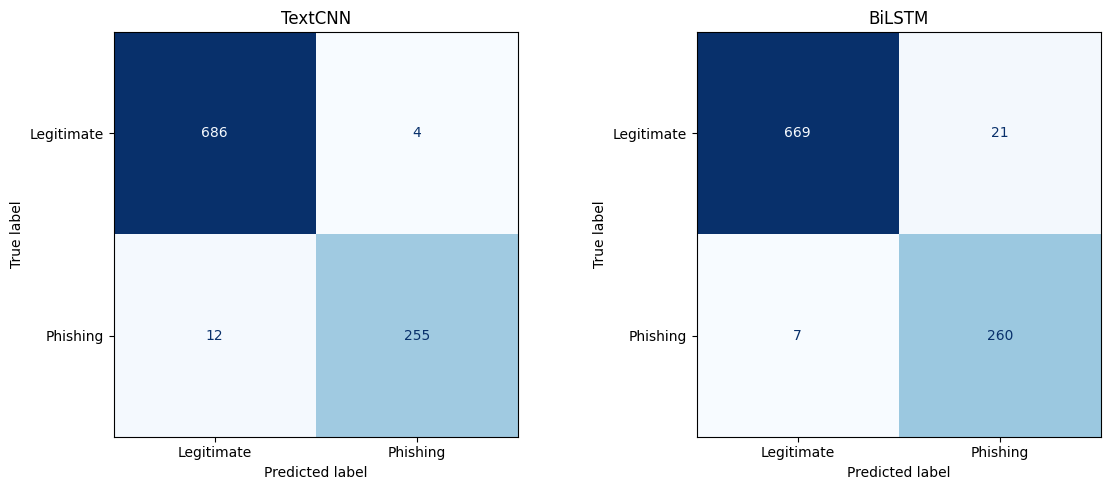

Confusion matrices saved.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, labels, preds, title, fname in [
    (axes[0], labels_cnn,  preds_cnn,  "TextCNN", "kaggle_cm_textcnn.png"),
    (axes[1], labels_lstm, preds_lstm, "BiLSTM",  "kaggle_cm_bilstm.png")
]:
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Phishing"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title)

plt.tight_layout()
plt.savefig(results_dir / "kaggle_dl_confusion_matrices.png", dpi=150)
plt.show()
print("Confusion matrices saved.")

## 12. Training Curves

Loss and validation F1 curves are plotted for both models across all epochs to visualise convergence behaviour and detect overfitting.

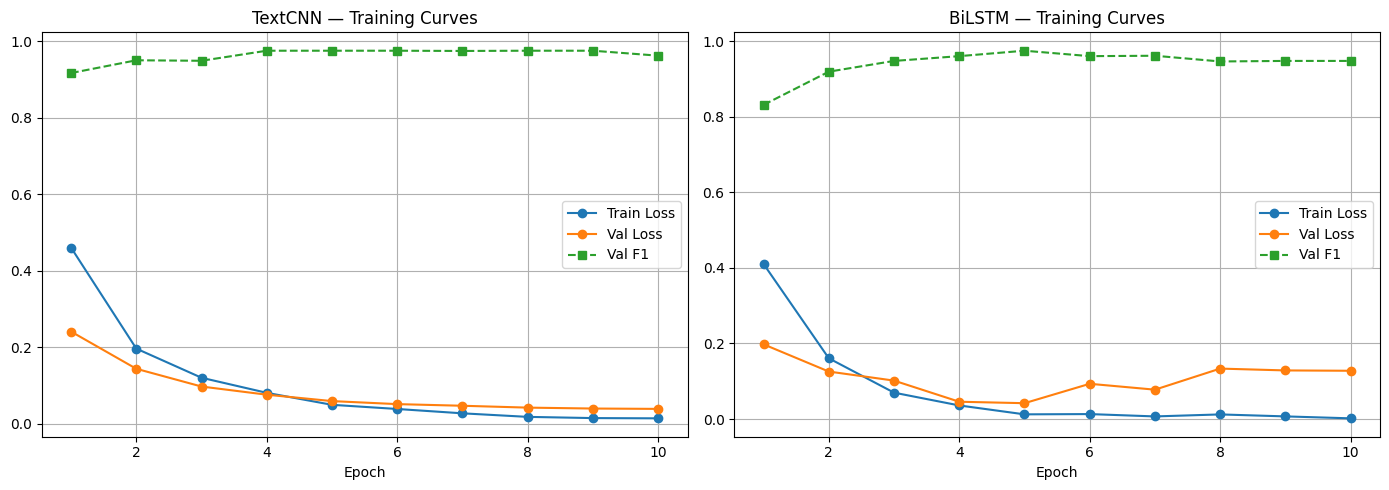

Training curves saved.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, history, title in [
    (axes[0], history_cnn,  "TextCNN"),
    (axes[1], history_lstm, "BiLSTM")
]:
    epochs = range(1, len(history["train_loss"]) + 1)
    ax.plot(epochs, history["train_loss"], label="Train Loss", marker="o")
    ax.plot(epochs, history["val_loss"],   label="Val Loss",   marker="o")
    ax.plot(epochs, history["val_f1"],     label="Val F1",     marker="s", linestyle="--")
    ax.set_title(f"{title} — Training Curves")
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig(results_dir / "kaggle_dl_training_curves.png", dpi=150)
plt.show()
print("Training curves saved.")

## 13. Save Results

Final metrics for both models are saved to a CSV file in the results folder, consistent with the output format of `meajor_dl_baseline_results.csv`.

In [13]:
results_df = pd.DataFrame([results_cnn, results_lstm])
csv_path   = results_dir / "kaggle_dl_results.csv"
results_df.to_csv(csv_path, index=False)

print(f"Results saved to {csv_path}")
results_df

Results saved to ../results/kaggle_dl_results.csv


,Model,Dataset,Accuracy,Precision,Recall,F1,FPR,Inference_ms
0,TextCNN,Kaggle,0.9833,0.9846,0.9551,0.9696,0.0058,1.4776
1,BiLSTM,Kaggle,0.9707,0.9253,0.9738,0.9489,0.0304,0.9181
